# 03 - Linear regression
**Concept: linear regression and the normal equation.** Model: $\hat y = Xw$. Minimize $J(w)=\frac1m\|Xw-y\|^2$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # make `src` importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_houses, to_arrays, FEATURES, TARGET
from src.preprocessing import train_test_split, Standardizer, add_bias, to_original_units
from src.model import LinearRegression, rmse, r2_score

## One feature first: slope and intercept from statistics
For $\hat y = a x + b$, minimizing the squared error gives:
$a = \frac{\mathrm{cov}(x,y)}{\mathrm{var}(x)}, \qquad b = \bar y - a\bar x$

price = 928.8 * size + 42,598


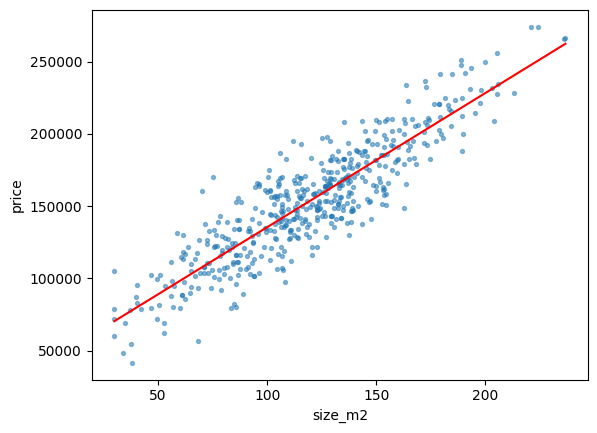

In [2]:
df = load_houses()
x, y1 = df['size_m2'].to_numpy(), df['price'].to_numpy()
a = np.mean((x - x.mean()) * (y1 - y1.mean())) / x.var()
b = y1.mean() - a * x.mean()
print(f'price = {a:.1f} * size + {b:,.0f}')

plt.scatter(x, y1, s=8, alpha=0.5)
xs_ = np.linspace(x.min(), x.max(), 100)
plt.plot(xs_, a * xs_ + b, color='red')
plt.xlabel('size_m2'); plt.ylabel('price'); plt.show()

## Many features: the normal equation
Setting the gradient to zero: $\nabla J = \frac{2}{m}X^T(Xw-y)=0 \Rightarrow X^TXw = X^Ty \Rightarrow w=(X^TX)^{-1}X^Ty$.
We use `np.linalg.solve` instead of an explicit inverse (faster, more stable).

In [3]:
X, y = to_arrays(df)
X_tr, X_te, y_tr, y_te = train_test_split(X, y)

# Raw units: no scaling needed for the closed form
Xb = add_bias(X_tr)
w = np.linalg.solve(Xb.T @ Xb, Xb.T @ y_tr)
print('weights (bias, size, bedrooms, age):', w.round(1))

weights (bias, size, bedrooms, age): [46227.5   910.1  3984.9  -537.8]


In [4]:
model = LinearRegression().fit_normal(X_tr, y_tr)
pred = model.predict(X_te)
print(f'RMSE = {rmse(y_te, pred):,.0f}')
print(f'R2   = {r2_score(y_te, pred):.4f}')

RMSE = 15,167
R2   = 0.8039


## Interpreting the weights
Each weight is the price change for +1 unit of that feature, other features fixed.

In [5]:
for name, wi in zip(['bias'] + FEATURES, model.w):
    print(f'{name:10s} {wi:>10,.1f}')

bias         46,227.5
size_m2         910.1
bedrooms      3,984.9
age_years      -537.8


## Residuals
If the model is right, residuals look like zero-mean Gaussian noise.

residual mean: 816.4 | std: 15145.3


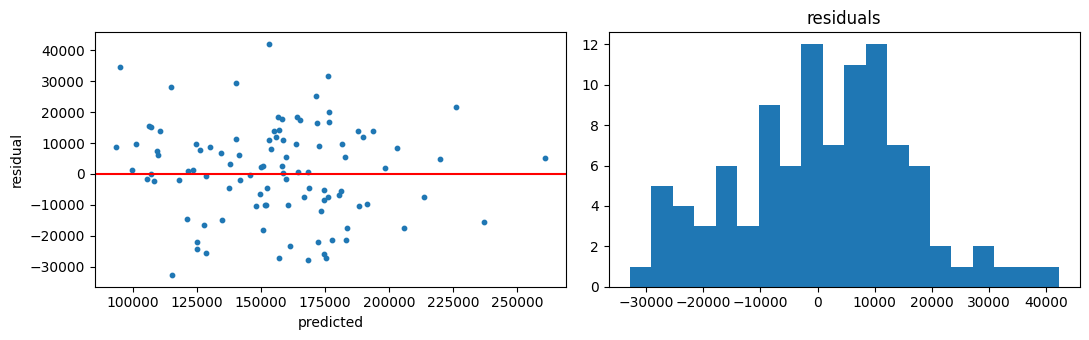

In [6]:
res = y_te - pred
print('residual mean:', res.mean().round(1), '| std:', res.std().round(1))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].scatter(pred, res, s=10); axes[0].axhline(0, color='red')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('residual')
axes[1].hist(res, bins=20); axes[1].set_title('residuals')
plt.tight_layout(); plt.show()

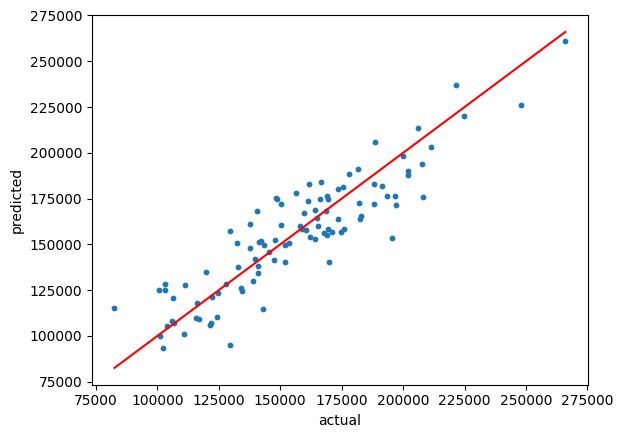

In [7]:
plt.scatter(y_te, pred, s=10)
lim = [y_te.min(), y_te.max()]
plt.plot(lim, lim, color='red'); plt.xlabel('actual'); plt.ylabel('predicted'); plt.show()